In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1" # A4500

In [2]:
import torch
from diffusers import QwenImageEditPipeline
from diffusers.utils import load_image

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = QwenImageEditPipeline.from_pretrained(
    "Qwen/Qwen-Image-Edit-2509",   # "Qwen/Qwen-Image-Edit"
    torch_dtype=torch.bfloat16,
)#.to(device)
pipe.enable_model_cpu_offload()  


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [3]:
# load lora weights
lora_repo = "lightx2v/Qwen-Image-Lightning"

pipe.load_lora_weights(
    lora_repo,
    weight_name="Qwen-Image-Edit-2509-Lightning-4steps-V1.0-bf16.safetensors",
    adapter_name="lightning_4steps",
)

# ComfyUI node LoraLoaderModelOnly equivalent
pipe.set_adapters("lightning_4steps", adapter_weights=[1.0])


OSError: lightx2v/Qwen-Image-Lightning does not appear to have a file named Qwen-Image-Edit-2509-Lightning-4steps-V1.0-bf16.safetensors.

In [4]:
import torch
from diffusers import DiffusionPipeline, FlowMatchEulerDiscreteScheduler   

# 1. load Qwen-Image-Edit base model (same source as the .safetensors in ComfyUI)
# Replace "Qwen/Qwen-Image-Edit-2509" with your actual HuggingFace repo
pipe = DiffusionPipeline.from_pretrained(
    "Qwen/Qwen-Image-Edit-2509",     # repo id = Qwen/Qwen-Image-Edit-2509
    torch_dtype=torch.bfloat16,       
)

# 2. replace scheduler 
pipe.scheduler = FlowMatchEulerDiscreteScheduler.from_config(pipe.scheduler.config)

# 3.（可选）替换自定义 VAE —— 对应你在 ComfyUI 里选的那个 VAE 节点
# 如果你在 ComfyUI 用的是单独 VAE safetensors，这里可以手动加载：
# from diffusers import AutoencoderKL
# vae = AutoencoderKL.from_single_file("/home/zzou/ComfyUI/models/vae/qwen_image_vae.safetensors", torch_dtype=torch.float16)
# pipe.vae = vae

# 4. add Lightning LoRA - ComfyUI 's “Lightning LoRA” noede
pipe.load_lora_weights(
    "ComfyUI/models/loras/Qwen-Image-Edit-2509-Lightning-4steps-V1.0-bf16.safetensors",       
    adapter_name="lightning"
)
pipe.set_adapters(["lightning"], [1.0])  # LoRA =1.0

pipe.enable_lora()
pipe.enable_sequential_cpu_offload() # save GPU memory very much, use only 1GB VRAM
# pipe.enable_model_cpu_offload() # using this one, when moving to GPU still gets OOM
# pipe.to("cuda") # get OOM directly if using this line

# 6. “4 steps lightning ” 
def edit_image_lightning(pipe, image, prompt, seed=42):
    """
    correspond to ComfyUI Qwen2.5-VL encoding + Qwen-Image-Edit-2509 UNet + 
    Lightning LoRA + KSampler(Euler, steps=4)
    """
    generator = torch.Generator(device="cuda").manual_seed(seed)

    out = pipe(
        prompt=prompt,          
        image=image,            
        num_inference_steps=4,  #  KSampler steps = 4 (Lightning)
        true_cfg_scale=1.0,  # Lightning LoRA default
        generator=generator,
        negative_prompt=" ",
    )
    return out.images[0]


# 7. 
def edit_image_20steps(pipe, image, prompt, seed=42):
    """
    correspond to ComfyUI: workflow KSampler steps=20。
    """
    generator = torch.Generator(device="cuda").manual_seed(seed)

    out = pipe(
        prompt=prompt,
        image=image,
        num_inference_steps=20,  # 对应 KSampler steps = 20
        guidance_scale=5.0,      
        generator=generator,
    )
    return out.images[0]


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [5]:
print(torch.cuda.memory_allocated(0))
next(pipe.transformer.parameters()).device


15360


device(type='meta')

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

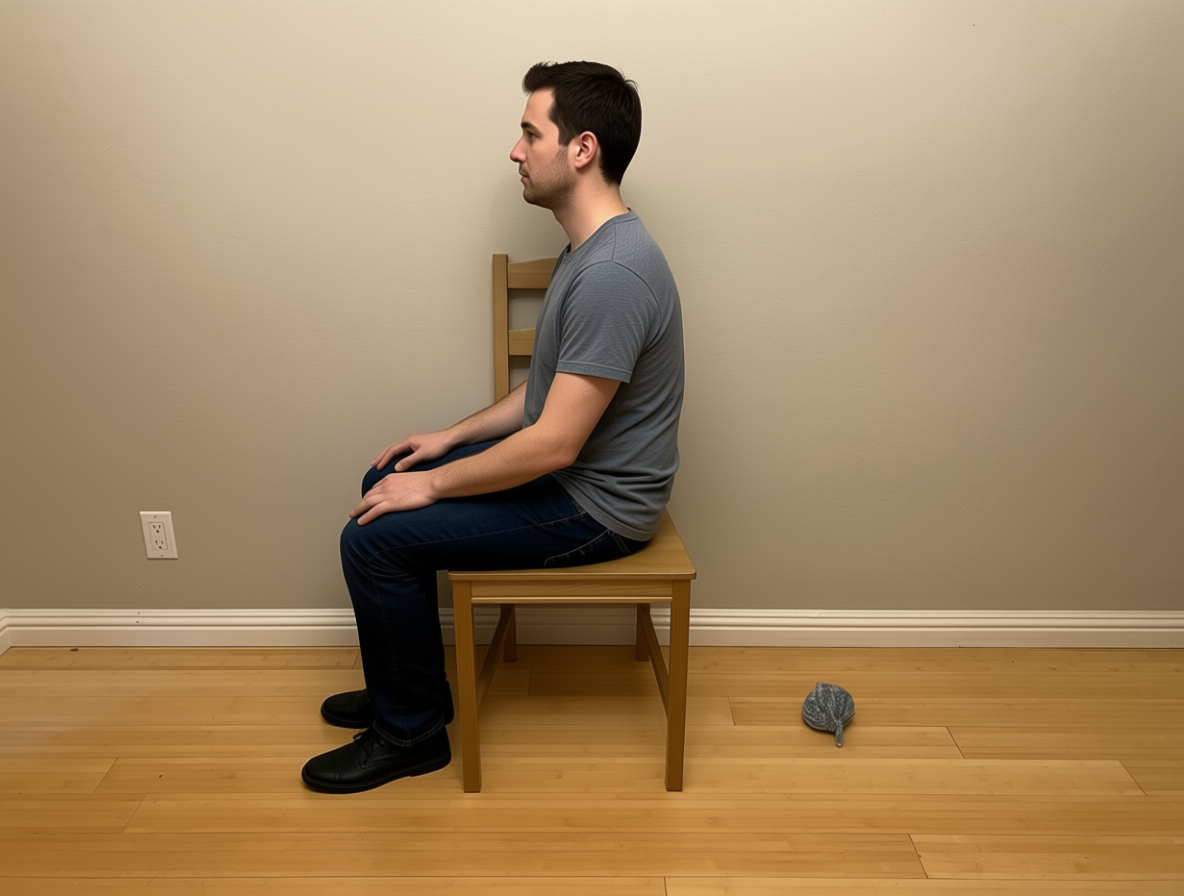

In [ ]:
# Example usage - 1 image edit with 4-step Lightning LoRA
from diffusers.utils import load_image

# 1. load initial image and set prompts
image = load_image("WhatsUp_dataset/controlled_images/ball-of-yarn_right_of_chair.jpeg").convert("RGB")
prompt = "Insert a human sitting on the chair facing left, with their body also turned to the left. Keep all the rest of the image the same."
negative_prompt = ""  # Corresponds to empty negative conditioning in your workflow

# 2. Call 4-step Lightning (corresponding to Raw latent + Lightning)
result = edit_image_lightning(pipe, image, prompt, seed=42)
result.save("qwen_image_edit_2509_HF_ball-of-yarn_right_FACELEFT.png")
result

### Edit image with chairs

In [4]:
import os, glob
import csv
from pathlib import Path

import torch
from tqdm import tqdm
from diffusers.utils import load_image


INPUT_DIR = Path("/home/zzou/WhatsUp_dataset/controlled_images")
OUTPUT_DIR = Path("/home/zzou/Version0_dataset/Qwen_Image_Edit_2509_v0")
META_CSV_DIR  = OUTPUT_DIR / "meta_v0.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EDIT_PROMPT_FACE_CAMERA_BASE  = ("Insert a human sitting on the chair facing the camera, with their body also faced the camera. Keep all the rest of the image the same.")
EDIT_PROMPT_FACE_LEFT_BASE  = ("Insert a human sitting on the chair facing left, with their body also turned to the left. Keep all the rest of the image the same.")
EDIT_PROMPT_FACE_RIGHT_BASE  = ("Insert a human sitting on the chair facing right, with their body also turned to the right. Keep all the rest of the image the same.")

# image search
image_paths = sorted(sum([
    glob.glob(f"{INPUT_DIR}/**/*.{ext}", recursive=True)
    for ext in ["jpg","jpeg","png","webp"]
], []))

print(f"Found in total {len(image_paths)} images under {INPUT_DIR}")
assert len(image_paths) > 0, "!!! No image detected !!!"

# filter base images
def match_name(fname: str) -> bool:
    fname = fname.lower()
    return ("_chair" in fname) and ("left" in fname or "right" in fname)

filtered_paths = [p for p in image_paths if match_name(os.path.basename(p))]
print(f"After filtering, will operate on {len(filtered_paths)} images.")


Found in total 421 images under /home/zzou/WhatsUp_dataset/controlled_images
After filtering, will operate on 90 images.


In [8]:
def generate_dataset_with_metadata(pipe, filtered_paths, meta_csv_path, input_dir, output_dir, edit_prompt_face_camera_base,edit_prompt_face_left_base,edit_prompt_face_right_base, seed=42,):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    meta_csv_path = Path(meta_csv_path)

    with meta_csv_path.open("w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(
            ["src_path", "dst_path", "prompt", "expected_direction", "second_object", "view_type"]
        )

        for idx, src in enumerate(tqdm(filtered_paths, desc="Processing images")):
            src = Path(src)

            img = load_image(str(src)).convert("RGB")

            second_object = src.name.split("_", 1)[0]
            EDIT_PROMPT_FACE_CAMERA = edit_prompt_face_camera_base.format(second_object=second_object)
            EDIT_PROMPT_FACE_LEFT   = edit_prompt_face_left_base.format(second_object=second_object)
            EDIT_PROMPT_FACE_RIGHT  = edit_prompt_face_right_base.format(second_object=second_object)

            rel = os.path.relpath(str(src), input_dir)
            dst_dir = output_dir / os.path.dirname(rel)
            dst_dir.mkdir(parents=True, exist_ok=True)
            base = os.path.splitext(os.path.basename(src))[0]

            # ------------------------------------------------------
            #  1. FACE-CAMERA
            # ------------------------------------------------------
            inputs = {
                "image": img,
                "prompt": EDIT_PROMPT_FACE_CAMERA,
                "negative_prompt": " ",
            }

            with torch.inference_mode():
                out_img = edit_image_lightning(
                    pipe,
                    image=img,
                    prompt=EDIT_PROMPT_FACE_CAMERA,
                    seed=seed + idx,
                )
                out_path = dst_dir / f"{base}_FACE-CAMERA.png"
                out_img.save(out_path)


            # expected direction of the second object in view of the human figure (face camera)
            filename_lower = src.name.lower()
            if "left" in filename_lower:
                expected_direction_face_front = "right"
            elif "right" in filename_lower:
                expected_direction_face_front = "left"
            else:
                expected_direction_face_front = "unknown"

            view_type = "FACE-CAMERA"
            writer.writerow(
                [str(src), str(out_path), EDIT_PROMPT_FACE_CAMERA, expected_direction_face_front, second_object, view_type])

            # ------------------------------------------------------
            #  2. FACE-LEFT
            # ------------------------------------------------------
            inputs = {
                "image": img,
                "prompt": EDIT_PROMPT_FACE_LEFT,
                "negative_prompt": " ",
            }

            with torch.inference_mode():
                out_img = edit_image_lightning(
                    pipe,
                    image=img,
                    prompt=EDIT_PROMPT_FACE_LEFT,
                    seed=seed + idx,
                )
                out_path = dst_dir / f"{base}_FACE-LEFT.png"
                out_img.save(out_path)

            # expected direction when human faces left
            if "left" in filename_lower:
                expected_direction_face_left = "front"
            elif "right" in filename_lower:
                expected_direction_face_left = "back"
            else:
                expected_direction_face_left = "unknown"

            view_type = "FACE-LEFT"
            writer.writerow(
                [str(src), str(out_path), EDIT_PROMPT_FACE_LEFT, expected_direction_face_left, second_object, view_type])

            # ------------------------------------------------------
            #  3. FACE-RIGHT
            # ------------------------------------------------------
            inputs = {
                "image": img,
                "prompt": EDIT_PROMPT_FACE_RIGHT,
                "negative_prompt": " ",
            }

            with torch.inference_mode():
                out_img = edit_image_lightning(
                    pipe,
                    image=img,
                    prompt=EDIT_PROMPT_FACE_RIGHT,
                    seed=seed + idx,
                )
                out_path = dst_dir / f"{base}_FACE-RIGHT.png"
                out_img.save(out_path)

            # expected direction when human faces right
            if "left" in filename_lower:
                expected_direction_face_right = "back"
            elif "right" in filename_lower:
                expected_direction_face_right = "front"
            else:
                expected_direction_face_right = "unknown"

            view_type = "FACE-RIGHT"
            writer.writerow(
                [str(src), str(out_path), EDIT_PROMPT_FACE_RIGHT, expected_direction_face_right, second_object, view_type])

    print(f"Saved images to {output_dir}")
    print(f"Metadata CSV saved to {meta_csv_path}")


In [ ]:
generate_dataset_with_metadata(
    pipe=pipe,
    filtered_paths=filtered_paths,
    meta_csv_path=META_CSV_DIR,
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    edit_prompt_face_camera_base=EDIT_PROMPT_FACE_CAMERA_BASE,
    edit_prompt_face_left_base=EDIT_PROMPT_FACE_LEFT_BASE,
    edit_prompt_face_right_base=EDIT_PROMPT_FACE_RIGHT_BASE,
    seed=0,
)


Processing images:   0%|          | 0/90 [00:00<?, ?it/s] negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


...

  0%|          | 0/4 [00:00<?, ?it/s]

Processing images:  42%|████▏     | 38/90 [1:26:28<1:58:22, 136.58s/it] negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

### Edit image with tables

In [4]:
import os, glob
import csv
from pathlib import Path

import torch
from tqdm import tqdm
from diffusers.utils import load_image


INPUT_DIR = Path("/home/zzou/WhatsUp_dataset/controlled_images")
TABLE_OUTPUT_DIR = Path("/home/zzou/Version0_dataset/Qwen_Image_Edit_2509_v0_table")
TABLE_META_CSV_DIR  = TABLE_OUTPUT_DIR / "meta_v0_table.csv"
os.makedirs(TABLE_OUTPUT_DIR, exist_ok=True)

TABLE_EDIT_PROMPT_FACE_CAMERA_BASE  = ("Remove the table. Insert a human standing facing the camera, with their body also faced the camera. Keep all the rest of the image the same.")
TABLE_EDIT_PROMPT_FACE_LEFT_BASE  = ("Remove the table. Insert a human standing facing left, with their body also turned to the left. Keep all the rest of the image the same.")
TABLE_EDIT_PROMPT_FACE_RIGHT_BASE  = ("Remove the table. Insert a human standing facing right, with their body also turned to the right. Keep all the rest of the image the same.")

# image search
image_paths = sorted(sum([
    glob.glob(f"{INPUT_DIR}/**/*.{ext}", recursive=True)
    for ext in ["jpg","jpeg","png","webp"]
], []))

print(f"Found in total {len(image_paths)} images under {INPUT_DIR}")
assert len(image_paths) > 0, "!!! No image detected !!!"

# filter base images
def match_name(fname: str) -> bool:
    fname = fname.lower()
    return ("_table" in fname) and ("left" in fname or "right" in fname)

filtered_paths = [p for p in image_paths if match_name(os.path.basename(p))]
print(f"After filtering, will operate on {len(filtered_paths)} images.")


Found in total 421 images under /home/zzou/WhatsUp_dataset/controlled_images
After filtering, will operate on 58 images.


In [7]:
generate_dataset_with_metadata(
    pipe=pipe,
    filtered_paths=filtered_paths,
    meta_csv_path=TABLE_META_CSV_DIR,
    input_dir=INPUT_DIR,
    output_dir=TABLE_OUTPUT_DIR,
    edit_prompt_face_camera_base=TABLE_EDIT_PROMPT_FACE_CAMERA_BASE,
    edit_prompt_face_left_base=TABLE_EDIT_PROMPT_FACE_LEFT_BASE,
    edit_prompt_face_right_base=TABLE_EDIT_PROMPT_FACE_RIGHT_BASE,
    seed=0,
)


Processing images:   0%|          | 0/58 [00:00<?, ?it/s] negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


...

  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

Processing images: 100%|██████████| 58/58 [2:14:18<00:00, 138.95s/it]

Saved images to /home/zzou/Version0_dataset/Qwen_Image_Edit_2509_v0_table
Metadata CSV saved to /home/zzou/Version0_dataset/Qwen_Image_Edit_2509_v0_table/meta_v0_table.csv


### Edit image with armchairs

In [6]:
import os, glob
import csv
from pathlib import Path

import torch
from tqdm import tqdm
from diffusers.utils import load_image


INPUT_DIR = Path("/home/zzou/WhatsUp_dataset/controlled_images")
ARMCHAIR_OUTPUT_DIR = Path("/home/zzou/Version0_dataset/Qwen_Image_Edit_2509_v0_armchair")
ARMCHAIR_META_CSV_DIR  = ARMCHAIR_OUTPUT_DIR / "meta_v0_armchair.csv"
os.makedirs(ARMCHAIR_OUTPUT_DIR, exist_ok=True)

ARMCHAIR_EDIT_PROMPT_FACE_CAMERA_BASE  = ("Insert a human sitting on the armchair facing the camera, with their body also faced the camera. Keep all the rest of the image the same.")
ARMCHAIR_EDIT_PROMPT_FACE_LEFT_BASE  = ("Insert a human sitting on the armchair facing left, with their body also turned to the left. Keep all the rest of the image the same. You can change the orientation of the armchair.")
ARMCHAIR_EDIT_PROMPT_FACE_RIGHT_BASE  = ("Insert a human sitting on the armchair facing right, with their body also turned to the right. Keep all the rest of the image the same. You can change the orientation of the armchair.")

# image search
image_paths = sorted(sum([
    glob.glob(f"{INPUT_DIR}/**/*.{ext}", recursive=True)
    for ext in ["jpg","jpeg","png","webp"]
], []))

print(f"Found in total {len(image_paths)} images under {INPUT_DIR}")
assert len(image_paths) > 0, "!!! No image detected !!!"

# filter base images
def match_name(fname: str) -> bool:
    fname = fname.lower()
    return ("_armchair" in fname) and ("left" in fname or "right" in fname)

filtered_paths = [p for p in image_paths if match_name(os.path.basename(p))]
print(f"After filtering, will operate on {len(filtered_paths)} images.")


Found in total 421 images under /home/zzou/WhatsUp_dataset/controlled_images
After filtering, will operate on 62 images.


In [9]:
generate_dataset_with_metadata(
    pipe=pipe,
    filtered_paths=filtered_paths,
    meta_csv_path=ARMCHAIR_META_CSV_DIR,
    input_dir=INPUT_DIR,
    output_dir=ARMCHAIR_OUTPUT_DIR,
    edit_prompt_face_camera_base=ARMCHAIR_EDIT_PROMPT_FACE_CAMERA_BASE,
    edit_prompt_face_left_base=ARMCHAIR_EDIT_PROMPT_FACE_LEFT_BASE,
    edit_prompt_face_right_base=ARMCHAIR_EDIT_PROMPT_FACE_RIGHT_BASE,
    seed=0,
)


Processing images:   0%|          | 0/62 [00:00<?, ?it/s] negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


...

  0%|          | 0/4 [00:00<?, ?it/s]

 negative_prompt is passed but classifier-free guidance is not enabled since true_cfg_scale <= 1


  0%|          | 0/4 [00:00<?, ?it/s]

Processing images: 100%|██████████| 62/62 [2:34:29<00:00, 149.51s/it]

Saved images to /home/zzou/Version0_dataset/Qwen_Image_Edit_2509_v0_armchair
Metadata CSV saved to /home/zzou/Version0_dataset/Qwen_Image_Edit_2509_v0_armchair/meta_v0_armchair.csv
